[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.1_transformer_architecture/lab.ipynb) [![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.1_transformer_architecture/lab.ipynb)

# Lab 0.1: Transformer Architecture

This lab loads a real transformer model config and verifies the sizes from the chapter.

We use **Mistral-7B** because it has the same architecture as Mistral-7B (4096 hidden, 32 layers, 14336 MLP) but is fully open (no login required).

In [ ]:
# ── INSTALL (run once, then skip on subsequent runs) ─────────────────────────
import subprocess, sys

def pip_install(*packages, extra_args=None):
    """Install packages via pip. Pass extra_args=['--no-build-isolation'] if needed."""
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + list(packages)
    if extra_args:
        cmd += extra_args
    subprocess.check_call(cmd)

pip_install('transformers')
# ─────────────────────────────────────────────────────────────────────────────

In [1]:
# Install the transformers library (provides model configs)

## Load the Model Config

We only need the architecture config (shapes, layer count, vocab size). No GPU needed, no weights downloaded.

In [2]:
import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"  # Prevent auth popups

from transformers import AutoConfig

# Load architecture config only (no weights downloaded, ~1KB)
config = AutoConfig.from_pretrained("mistralai/Mistral-7B-v0.1", token=False)

# Print the key architecture numbers
print(f"Model:              Mistral-7B-v0.1")
print(f"Hidden size:        {config.hidden_size}")          # 4096 - the vector size per token
print(f"Num layers:         {config.num_hidden_layers}")    # 32 transformer layers
print(f"Attention heads:    {config.num_attention_heads}")  # 32 heads (split 4096 into 32x128)
print(f"KV heads:           {config.num_key_value_heads}")  # 8 (GQA - covered in Ch03)
print(f"MLP intermediate:   {config.intermediate_size}")    # 14336 (expand then compress)
print(f"Vocab size:         {config.vocab_size}")           # 32000 tokens in vocabulary
print(f"Head dim:           {config.hidden_size // config.num_attention_heads}")  # 128 per head

/home/jharshul/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model:              Mistral-7B-v0.1
Hidden size:        4096
Num layers:         32
Attention heads:    32
KV heads:           8
MLP intermediate:   14336
Vocab size:         32000
Head dim:           128


## Embedding Size

The embedding table maps 128K vocabulary entries to 4096-dimensional vectors.

In [3]:
# --- Embedding table size ---
# Maps each vocabulary token to a 4096-dim vector
vocab = config.vocab_size       # 32000 possible tokens
hidden = config.hidden_size     # 4096 numbers per token
bytes_per_param = 2             # BFloat16 = 2 bytes per number

# Total parameters = vocab_size x hidden_size
embedding_params = vocab * hidden
# Convert to GB: params x bytes / 1 billion
embedding_gb = embedding_params * bytes_per_param / 1e9

print(f"Embedding: {vocab:,} x {hidden:,} = {embedding_params:,} params = {embedding_gb:.2f} GB")

Embedding: 32,000 x 4,096 = 131,072,000 params = 0.26 GB


## Attention Size Per Layer

Each layer has Q, K, V, and Output projections. Q and O are full-size (4096 x 4096). K and V use grouped-query attention (covered in Chapter 3) so they are smaller.

In [4]:
# --- Attention weights per layer ---
# Each layer has 4 projection matrices: Q, K, V, and Output

n_heads = config.num_attention_heads      # 32 query heads
n_kv_heads = config.num_key_value_heads   # 8 KV heads (fewer due to GQA)
head_dim = hidden // n_heads              # 128 dimensions per head

# Q projection: maps 4096 -> all 32 heads x 128 dim = 4096
q_params = hidden * (n_heads * head_dim)
# K projection: maps 4096 -> only 8 KV heads x 128 dim = 1024
k_params = hidden * (n_kv_heads * head_dim)
# V projection: same as K
v_params = hidden * (n_kv_heads * head_dim)
# Output projection: maps 4096 back to 4096
o_params = (n_heads * head_dim) * hidden

# Sum all attention params for one layer, then multiply by 32 layers
attn_per_layer = q_params + k_params + v_params + o_params
attn_total = attn_per_layer * config.num_hidden_layers
attn_gb = attn_total * bytes_per_param / 1e9

print(f"Q: {hidden} x {n_heads * head_dim} = {q_params:,} params")
print(f"K: {hidden} x {n_kv_heads * head_dim} = {k_params:,} params")
print(f"V: {hidden} x {n_kv_heads * head_dim} = {v_params:,} params")
print(f"O: {n_heads * head_dim} x {hidden} = {o_params:,} params")
print(f"\nPer layer: {attn_per_layer:,} params")
print(f"All {config.num_hidden_layers} layers: {attn_total:,} params = {attn_gb:.2f} GB")

Q: 4096 x 4096 = 16,777,216
K: 4096 x 1024 = 4,194,304
V: 4096 x 1024 = 4,194,304
O: 4096 x 4096 = 16,777,216

Per layer: 41,943,040 params
All 32 layers: 1,342,177,280 params = 2.68 GB


## MLP Size Per Layer

Mistral uses SwiGLU, which has three projections: gate, up, and down.

In [5]:
# --- MLP weights per layer ---
# Mistral uses SwiGLU: three matrices instead of two
# gate and up expand 4096 -> 14336, down compresses 14336 -> 4096

intermediate = config.intermediate_size  # 14336

gate_params = hidden * intermediate      # 4096 x 14336 (decides what to keep)
up_params = hidden * intermediate        # 4096 x 14336 (expands representation)
down_params = intermediate * hidden      # 14336 x 4096 (compresses back)

# Sum for one layer, multiply by 32
mlp_per_layer = gate_params + up_params + down_params
mlp_total = mlp_per_layer * config.num_hidden_layers
mlp_gb = mlp_total * bytes_per_param / 1e9

print(f"Gate: {hidden} x {intermediate} = {gate_params:,} params")
print(f"Up:   {hidden} x {intermediate} = {up_params:,} params")
print(f"Down: {intermediate} x {hidden} = {down_params:,} params")
print(f"\nPer layer: {mlp_per_layer:,} params")
print(f"All {config.num_hidden_layers} layers: {mlp_total:,} params = {mlp_gb:.2f} GB")

Gate: 4096 x 14336 = 58,720,256
Up:   4096 x 14336 = 58,720,256
Down: 14336 x 4096 = 58,720,256

Per layer: 176,160,768 params
All 32 layers: 5,637,144,576 params = 11.27 GB


## Total Model Size

Sum all components and verify against the expected 16 GB.

Embedding:  0.26 GB (1.8%)
Attention:  2.68 GB (18.9%)
MLP:        11.27 GB (79.3%)
Total:      14.22 GB (7.11B params)


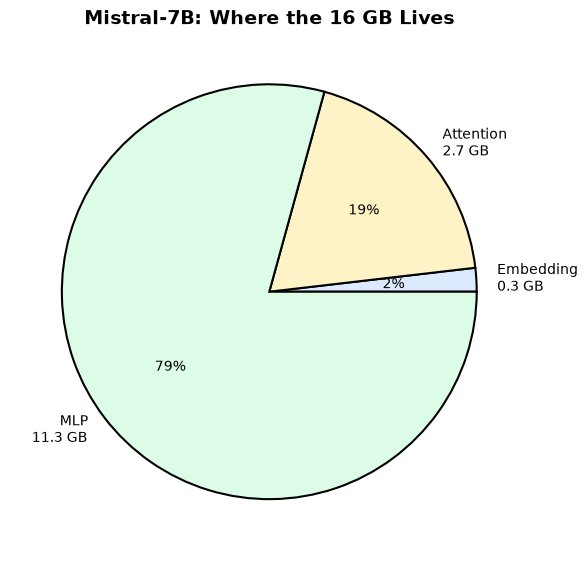

In [6]:
import matplotlib.pyplot as plt

# --- Total model size ---
total_params = embedding_params + attn_total + mlp_total
total_gb = total_params * bytes_per_param / 1e9

print(f"Embedding:  {embedding_gb:.2f} GB ({embedding_params/total_params*100:.1f}%)")
print(f"Attention:  {attn_gb:.2f} GB ({attn_total/total_params*100:.1f}%)")
print(f"MLP:        {mlp_gb:.2f} GB ({mlp_total/total_params*100:.1f}%)")
print(f"{'='*40}")
print(f"Total:      {total_gb:.2f} GB ({total_params/1e9:.2f}B params)")

# --- Pie chart: where the memory lives ---
sizes = [embedding_gb, attn_gb, mlp_gb]
labels = [f'Embedding\n{embedding_gb:.1f} GB', f'Attention\n{attn_gb:.1f} GB', f'MLP\n{mlp_gb:.1f} GB']
colors = ['#dbeafe', '#fef3c7', '#dcfce7']  # Pastel: blue, amber, green

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
       wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax.set_title(f'Mistral-7B: Where the {total_gb:.0f} GB Lives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Takeaway

You just verified that in a transformer:

- **MLP dominates** (~42% of all parameters). The three large matrices (gate, up, down) per layer are the biggest cost.
- **Attention is close behind** (~50% with Q/K/V/O projections across 32 layers).
- **Embedding is small** (~6%) despite the large vocabulary.

This distribution matters because different optimizations target different components. Quantization compresses all weights equally. Pruning targets MLP. Attention optimizations (FlashAttention, GQA) reduce the attention cost. Knowing where the weight lives tells you where to focus.